In [1]:
#Conexão Inicial e Banco de Dados
import mysql.connector

conexao = mysql.connector.connect(
    host="localhost",
    user = "root",
    password = "root"
)

print("Conexão Iniciada")

Conexão Iniciada


In [2]:
#Criar Banco

cursor = conexao.cursor()

cursor.execute("CREATE DATABASE IF NOT EXISTS glow_cosmeticos")
print("Banco Criado com Sucesso!")

Banco Criado com Sucesso!


In [3]:
cursor.execute("USE glow_cosmeticos")

print("Comando executado com sucesso!")

Comando executado com sucesso!


1. Relatório de Volume de Portfólio por Categoria

 Objetivo: Descobrir quais categorias possuem a maior variedade de
produtos cadastrados para entender o foco do catálogo.

 Desafio SQL/Python: Unir as tabelas (JOIN), agrupar pelo nome da
categoria (GROUP BY) para contar a quantidade de produtos
(COUNT), e ordenar o resultado da categoria com mais variedade
para a com menos (ORDER BY decrescente).

Exiba o resultado em um gráfico de
barras horizontais.


In [45]:
comando_relatorio_volume = '''
SELECT
    categorias.nome,
    COUNT(*)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY count(produtos.estoque) desc;
'''

cursor.execute(comando_relatorio_volume)
relatorio_volume = cursor.fetchall()

print("\n--- Portifólio por Categoria  ---\n")

for i in relatorio_volume:
    print(f"Categoria: {i[0]} | Quantidade: {i[1]}")




--- Portifólio por Categoria  ---

Categoria: Maquiagem | Quantidade: 6
Categoria: Cuidados com a Pele | Quantidade: 4
Categoria: Cuidados com o Cabelo | Quantidade: 4
Categoria: Perfumes e Fragrâncias | Quantidade: 3
Categoria: Higiene Pessoal | Quantidade: 3
Categoria: Proteção Solar | Quantidade: 2
Categoria: Produtos Anti-idade | Quantidade: 2
Categoria: Dermocosméticos | Quantidade: 2
Categoria: Produtos Naturais e Orgânicos | Quantidade: 2
Categoria: Cuidados Masculinos | Quantidade: 2


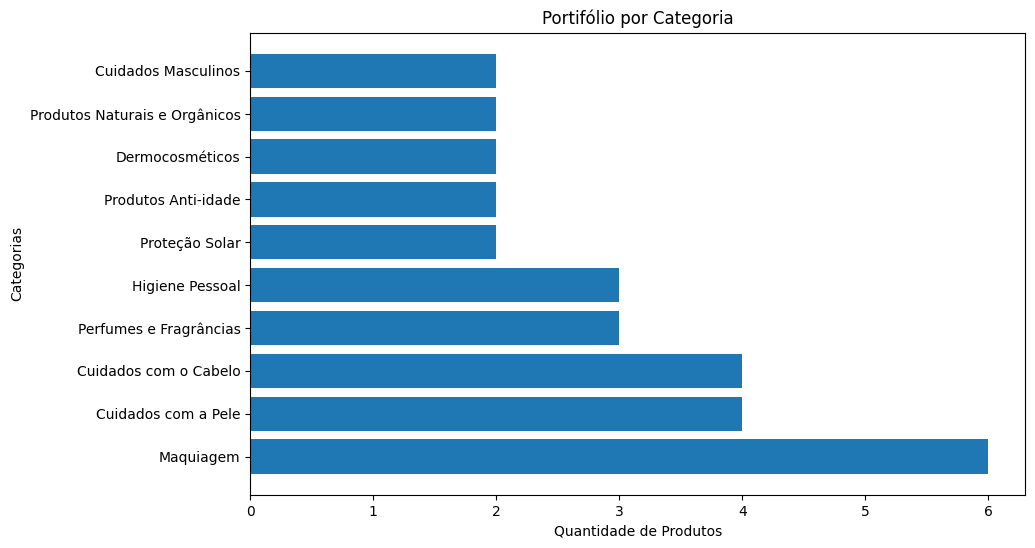

In [46]:
import matplotlib.pyplot as plt 

categorias = [linha[0] for linha in relatorio_volume]
quantidade = [coluna[1] for coluna in relatorio_volume]

plt.figure(figsize=(10,6))

plt.barh(categorias, quantidade)

plt.xlabel("Quantidade de Produtos")
plt.ylabel("Categorias")
plt.title("Portifólio por Categoria")

plt.show()

2. Análise de Preço Médio (Ticket Médio) por Setor

 Objetivo: Identificar quais setores da loja (ex: Skincare, Batons)
possuem a maior média de preço de venda.

 Desafio SQL/Python: Unir as tabelas, agrupar por categoria para
calcular o preço médio de mercado (AVG), e ordenar os resultados
do maior preço médio para o menor.

Apresente os dados em um gráfico de colunas.

In [47]:
comando_analise_preco_medio='''
SELECT
    categorias.nome,
    AVG(produtos.preco)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY AVG(produtos.preco) DESC;
'''

cursor.execute(comando_analise_preco_medio)
analise_preco_medio = cursor.fetchall()

print("\n--- Preço Médio ---\n")

for i in analise_preco_medio:
    print(f"Categoria: {i[0]} | Preço Médio: {i[1]:.2f}")






--- Preço Médio ---

Categoria: Perfumes e Fragrâncias | Preço Médio: 99.30
Categoria: Produtos Anti-idade | Preço Médio: 82.45
Categoria: Dermocosméticos | Preço Médio: 68.95
Categoria: Proteção Solar | Preço Médio: 42.70
Categoria: Maquiagem | Preço Médio: 38.85
Categoria: Cuidados com o Cabelo | Preço Médio: 38.40
Categoria: Produtos Naturais e Orgânicos | Preço Médio: 33.95
Categoria: Cuidados Masculinos | Preço Médio: 29.45
Categoria: Cuidados com a Pele | Preço Médio: 26.55
Categoria: Higiene Pessoal | Preço Médio: 16.23


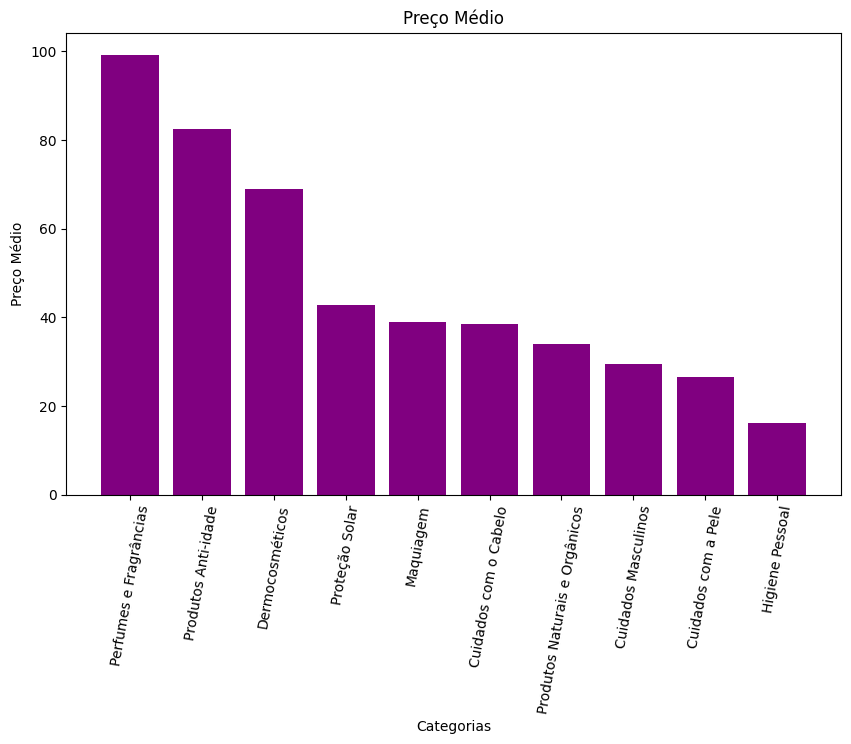

In [50]:
import matplotlib.pyplot as plt 

categorias = [linha[0] for linha in analise_preco_medio]
quantidade = [coluna[1] for coluna in analise_preco_medio]

plt.figure(figsize=(10,6))

plt.bar(categorias, quantidade,color="purple")

plt.xlabel("Categorias")
plt.ylabel("Preço Médio")
plt.title("Preço Médio")

plt.xticks(rotation=80)


plt.show()

3. Capital Parado (Valor Total em Estoque)

 Objetivo: Fornecer ao setor financeiro o valor total investido em
mercadoria parada no estoque por categoria.

 Desafio SQL/Python: Cruzar os dados, agrupar por categoria e
realizar a soma do cálculo de multiplicação (SUM(preco * estoque)),
ordenando o relatório pelo maior valor financeiro estocado.

Exiba os dados em um gráfico de pizza.

In [51]:
comando_capital_parado='''
SELECT
    categorias.nome,
    SUM((produtos.preco*produtos.estoque))
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY SUM((produtos.preco*produtos.estoque)) DESC;
'''

cursor.execute(comando_capital_parado)
capital_parado = cursor.fetchall()

print("\n--- Capital Parado ---\n")

for i in capital_parado:
    print(f"Categoria: {i[0]} | Total Investido: {i[1]:.2f}")





--- Capital Parado ---

Categoria: Maquiagem | Total Investido: 8104.50
Categoria: Perfumes e Fragrâncias | Total Investido: 5926.50
Categoria: Cuidados com o Cabelo | Total Investido: 5106.50
Categoria: Cuidados com a Pele | Total Investido: 4908.00
Categoria: Dermocosméticos | Total Investido: 4137.00
Categoria: Proteção Solar | Total Investido: 4126.00
Categoria: Produtos Anti-idade | Total Investido: 3673.00
Categoria: Higiene Pessoal | Total Investido: 3299.50
Categoria: Produtos Naturais e Orgânicos | Total Investido: 2974.00
Categoria: Cuidados Masculinos | Total Investido: 1742.50


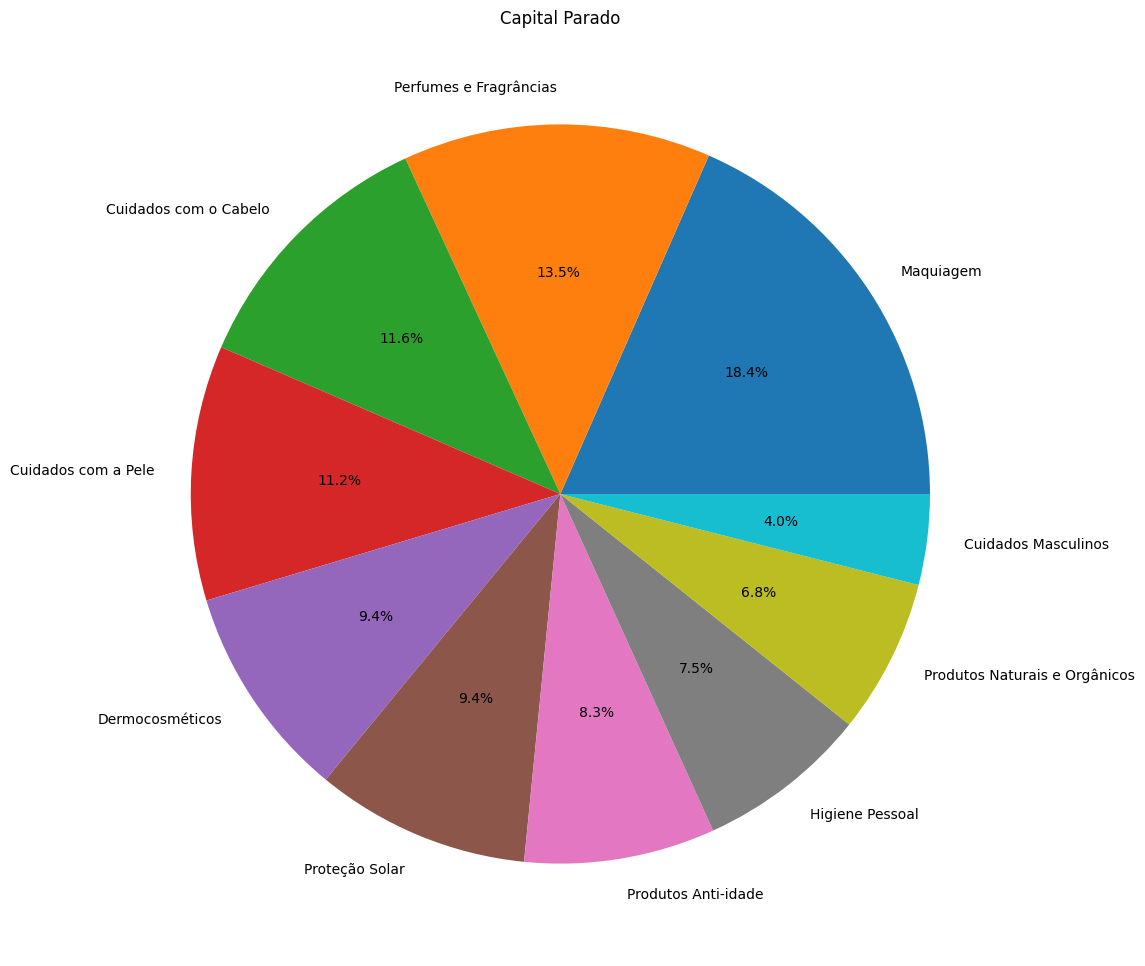

In [52]:
import matplotlib.pyplot as plt 

categorias = [linha[0] for linha in capital_parado]
totalInvestido = [coluna[1] for coluna in capital_parado]


plt.figure(figsize=(12,12))

plt.pie(totalInvestido,labels=categorias,autopct="%1.1f%%")
plt.title("Capital Parado")

plt.show()

4. Alerta de Reposição Crítica de Estoque

 Objetivo: Listar a quantidade de produtos que estão com estoque
baixo (ex: menos de 50 unidades), agrupados por categoria, para
planejar compras.

 Desafio SQL/Python: Filtrar produtos com estoque baixo (WHERE
estoque < 50), juntar com as categorias, agrupar para contar quantos
itens estão nessa situação crítica e ordenar pela categoria mais
urgente (com maior número de produtos desfalcados).

Gere um gráfico de colunas para o setor de compras.

In [53]:
#O número de alerta será de 100 porque 50 é muito baixo para o alerta
comando_alerta_reposicao='''
SELECT
    categorias.nome,
    SUM(produtos.estoque)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
HAVING SUM(produtos.estoque) < 100
ORDER BY SUM(produtos.estoque) DESC;
'''

cursor.execute(comando_alerta_reposicao)
alerta_reposicao_critica = cursor.fetchall()

print("\n--- Alerta de Reposição ---\n")

for i in alerta_reposicao_critica:
    print(f"Categoria: {i[0]} | Estoque: {i[1]}")


--- Alerta de Reposição ---

Categoria: Perfumes e Fragrâncias | Estoque: 70
Categoria: Dermocosméticos | Estoque: 60
Categoria: Cuidados Masculinos | Estoque: 60
Categoria: Produtos Anti-idade | Estoque: 45


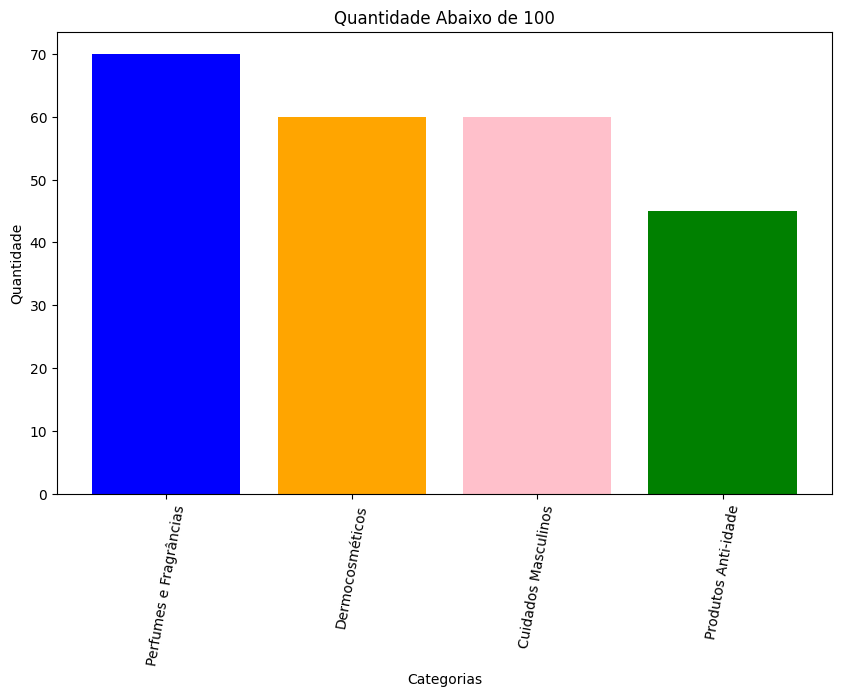

In [57]:
import matplotlib.pyplot as plt 

cores = ["blue","orange","pink","green"]

categorias = [linha[0] for linha in alerta_reposicao_critica]
quantidade = [coluna[1] for coluna in alerta_reposicao_critica]
cores_barras = [cor for cor in cores]


plt.figure(figsize=(10,6))

plt.bar(categorias, quantidade,color = cores_barras)

plt.xlabel("Categorias")
plt.ylabel("Quantidade")
plt.title("Quantidade Abaixo de 100")


plt.xticks(rotation=80)


plt.show()

5. Vitrine Premium (Produtos Mais Caros de Cada Linha)

 Objetivo: Mapear o cosmético de maior valor (topo de linha) em
cada uma das categorias para campanhas de marketing de luxo.

 Desafio SQL/Python: Realizar o JOIN, agrupar pelo nome da
categoria para extrair o valor máximo (MAX(preco)) e ordenar o
relatório final do maior preço para o menor.

Plote um gráfico de linhas com marcadores.

In [58]:
comando_vitrine_premium='''
SELECT
    categorias.nome,
    MAX(produtos.preco)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY MAX(produtos.preco) DESC;

'''

cursor.execute(comando_vitrine_premium)
vitrine_premium = cursor.fetchall()

print("\n--- Vitrine Premium ---\n")

for i in vitrine_premium:
    print(f"Categoria: {i[0]} | Preço: {i[1]:.2f}")


--- Vitrine Premium ---

Categoria: Perfumes e Fragrâncias | Preço: 135.00
Categoria: Dermocosméticos | Preço: 98.00
Categoria: Produtos Anti-idade | Preço: 89.90
Categoria: Maquiagem | Preço: 79.90
Categoria: Produtos Naturais e Orgânicos | Preço: 55.00
Categoria: Cuidados com o Cabelo | Preço: 49.90
Categoria: Proteção Solar | Preço: 49.90
Categoria: Cuidados com a Pele | Preço: 32.90
Categoria: Cuidados Masculinos | Preço: 31.90
Categoria: Higiene Pessoal | Preço: 17.90


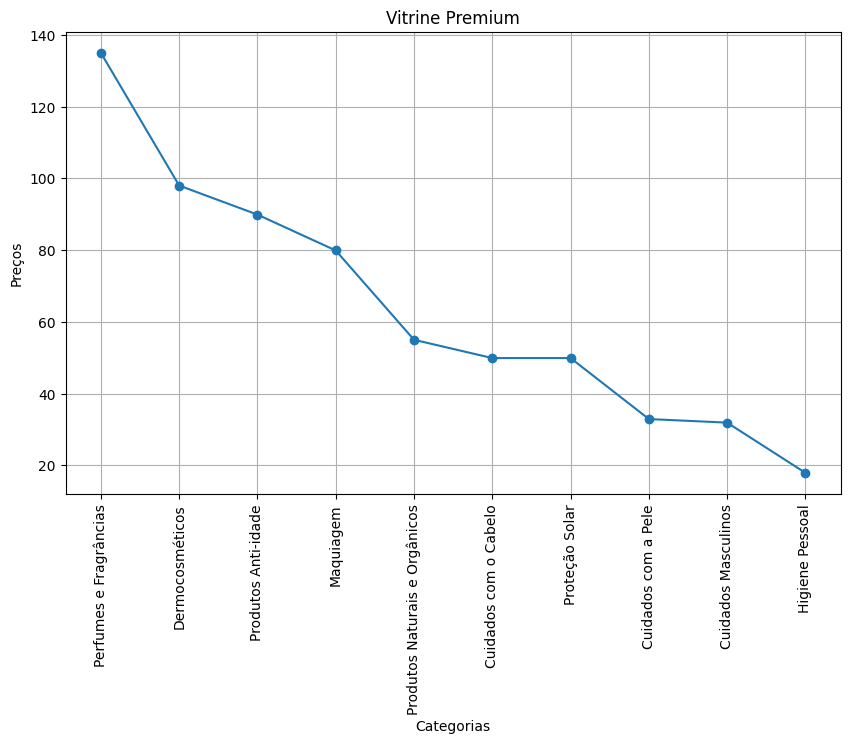

In [59]:
import matplotlib.pyplot as plt 

categorias = [linha[0] for linha in vitrine_premium]
precos = [coluna[1] for coluna in vitrine_premium]

plt.figure(figsize=(10,6))

plt.plot(categorias, precos, marker="o")

plt.xlabel("Categorias")
plt.ylabel("Preços")
plt.title("Vitrine Premium")

plt.xticks(rotation=90)
plt.grid(True)


plt.show()

6. Linha de Entrada (Produtos Mais Baratos de Cada Linha)

 Objetivo: Descobrir o produto mais acessível de cada categoria para
criar uma campanha de promoções "a partir de R$ X".

 Desafio SQL/Python: Unir as tabelas, agrupar por categoria para
encontrar o valor mínimo (MIN(preco)) e ordenar os resultados do
menor preço para o maior.

Construa um gráfico de barras horizontais.

In [60]:
comando_produtos_mais_baratos_categorias='''
SELECT
    categorias.nome,
    MIN(produtos.preco)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY MIN(produtos.preco) ASC;

'''

cursor.execute(comando_produtos_mais_baratos_categorias)
produtos_mais_baratos_categorias = cursor.fetchall()

print("\n--- Produtos Mais Baratos ---\n")

for i in produtos_mais_baratos_categorias:
    print(f"Categoria: {i[0]} | Preço: {i[1]}")


--- Produtos Mais Baratos ---

Categoria: Produtos Naturais e Orgânicos | Preço: 12.90
Categoria: Higiene Pessoal | Preço: 14.90
Categoria: Cuidados com a Pele | Preço: 18.50
Categoria: Maquiagem | Preço: 19.90
Categoria: Cuidados Masculinos | Preço: 27.00
Categoria: Cuidados com o Cabelo | Preço: 28.90
Categoria: Proteção Solar | Preço: 35.50
Categoria: Dermocosméticos | Preço: 39.90
Categoria: Perfumes e Fragrâncias | Preço: 42.90
Categoria: Produtos Anti-idade | Preço: 75.00


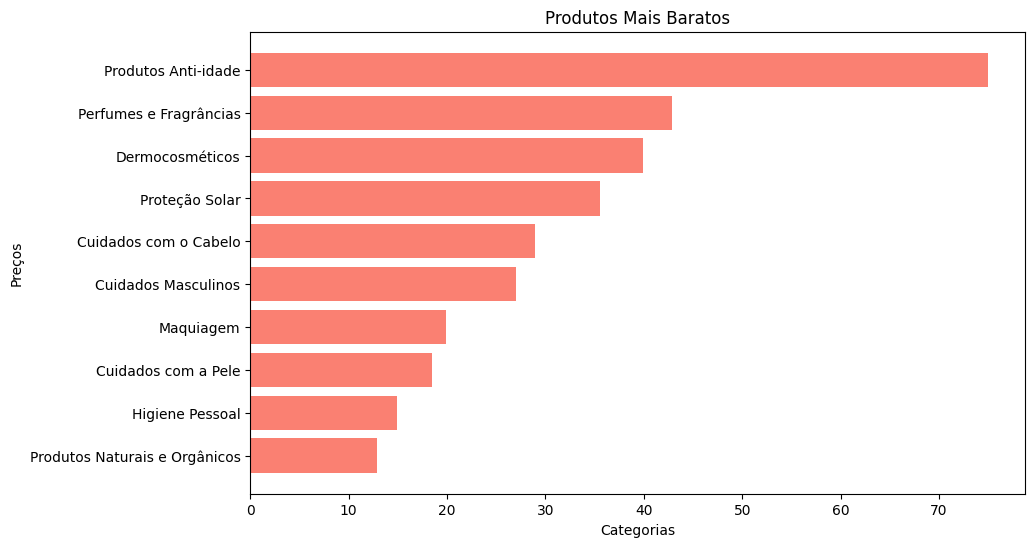

In [62]:
import matplotlib.pyplot as plt 

categorias = [linha[0] for linha in produtos_mais_baratos_categorias]
precos = [coluna[1] for coluna in produtos_mais_baratos_categorias]

plt.figure(figsize=(10,6))

plt.barh(categorias, precos,color = "salmon")

plt.xlabel("Categorias")
plt.ylabel("Preços")
plt.title("Produtos Mais Baratos")



plt.show()

7. Auditoria de Volume Físico no Galpão

 Objetivo: Contar a quantidade exata de itens físicos (unidades totais)
presentes no estoque, divididos por setor de beleza.

 Desafio SQL/Python: Unir as tabelas, agrupar por categoria para
somar o volume de unidades total (SUM(estoque)) e ordenar de
forma decrescente para saber quais categorias ocupam mais espaço
físico no galpão.

Exiba os resultados em um gráfico de colunas.

In [63]:
comando_volume_fisico='''
SELECT
    categorias.nome,
    SUM(produtos.estoque)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY SUM(produtos.estoque) DESC;

'''

cursor.execute(comando_volume_fisico)
volume_fisico = cursor.fetchall()

print("\n--- Volume Físico ---\n")

for i in volume_fisico:
    print(f"Categoria: {i[0]} | Quantidade: {i[1]}")


--- Volume Físico ---

Categoria: Maquiagem | Quantidade: 245
Categoria: Higiene Pessoal | Quantidade: 205
Categoria: Cuidados com a Pele | Quantidade: 180
Categoria: Cuidados com o Cabelo | Quantidade: 135
Categoria: Proteção Solar | Quantidade: 100
Categoria: Produtos Naturais e Orgânicos | Quantidade: 100
Categoria: Perfumes e Fragrâncias | Quantidade: 70
Categoria: Dermocosméticos | Quantidade: 60
Categoria: Cuidados Masculinos | Quantidade: 60
Categoria: Produtos Anti-idade | Quantidade: 45


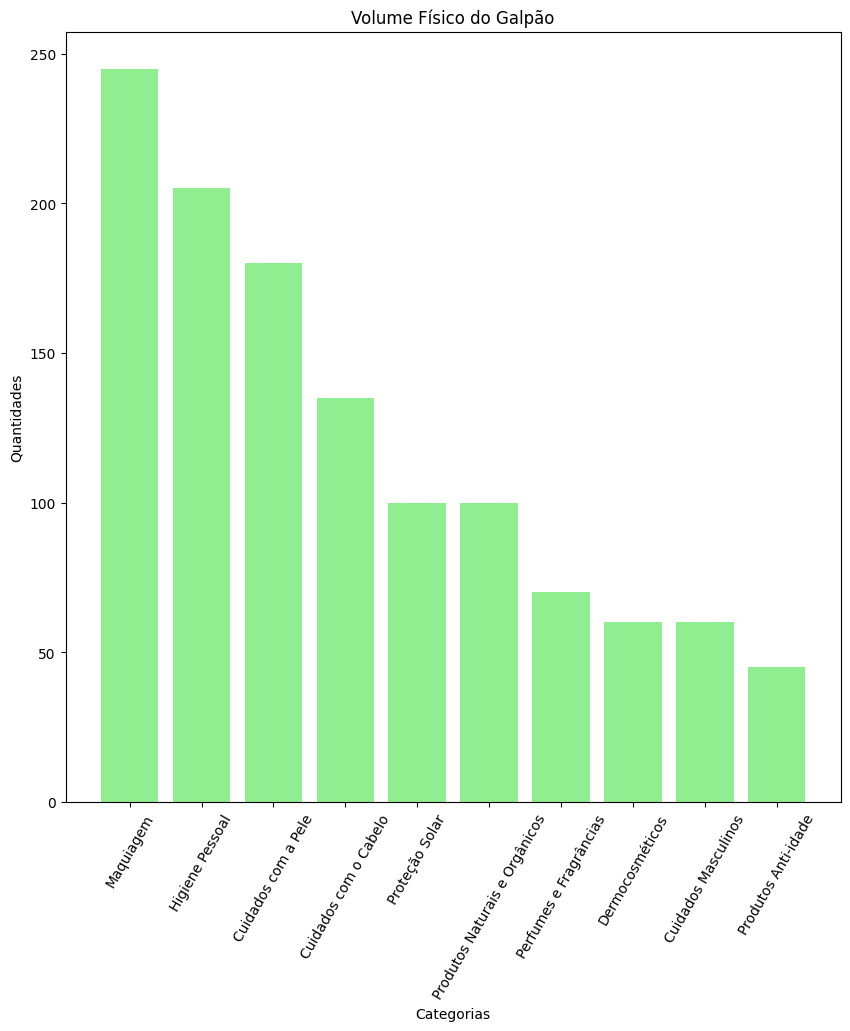

In [89]:
import matplotlib.pyplot as plt

categorias = [categoria[0] for categoria in volume_fisico]
quantidades = [quantidade[1] for quantidade in volume_fisico]

plt.figure(figsize=(10,10))

plt.bar(categorias,quantidades,color="lightgreen")

plt.xlabel("Categorias")
plt.ylabel("Quantidades")
plt.title("Volume Físico do Galpão")

plt.xticks(rotation = 60)

plt.show()

8. Painel de Categorias de Alto Padrão (Filtro Especial)

 Objetivo: Listar apenas as categorias cuja média de preço dos
produtos seja estritamente maior que R$ 60,00.

 Desafio SQL/Python: Cruzar as tabelas, agrupar por categoria,
aplicar a condição de filtro de grupo usando o HAVING AVG(preco) > 60 e ordenar em ordem alfabética pelo nome da categoria.

Visualize os dados em um gráfico de colunas.

In [66]:
comando_categorias_alto_padrao='''
SELECT
    categorias.nome,
    AVG(produtos.preco)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
HAVING AVG(produtos.preco)>60
ORDER BY categorias.nome ASC;
'''

cursor.execute(comando_categorias_alto_padrao)
categorias_alto_padrao = cursor.fetchall()

print("\n--- Categorias de Alto Padrão ---\n")

for i in categorias_alto_padrao:
    print(f"Categoria: {i[0]} | Preço Médio: {i[1]:.2f}")



--- Categorias de Alto Padrão ---

Categoria: Dermocosméticos | Preço Médio: 68.95
Categoria: Perfumes e Fragrâncias | Preço Médio: 99.30
Categoria: Produtos Anti-idade | Preço Médio: 82.45


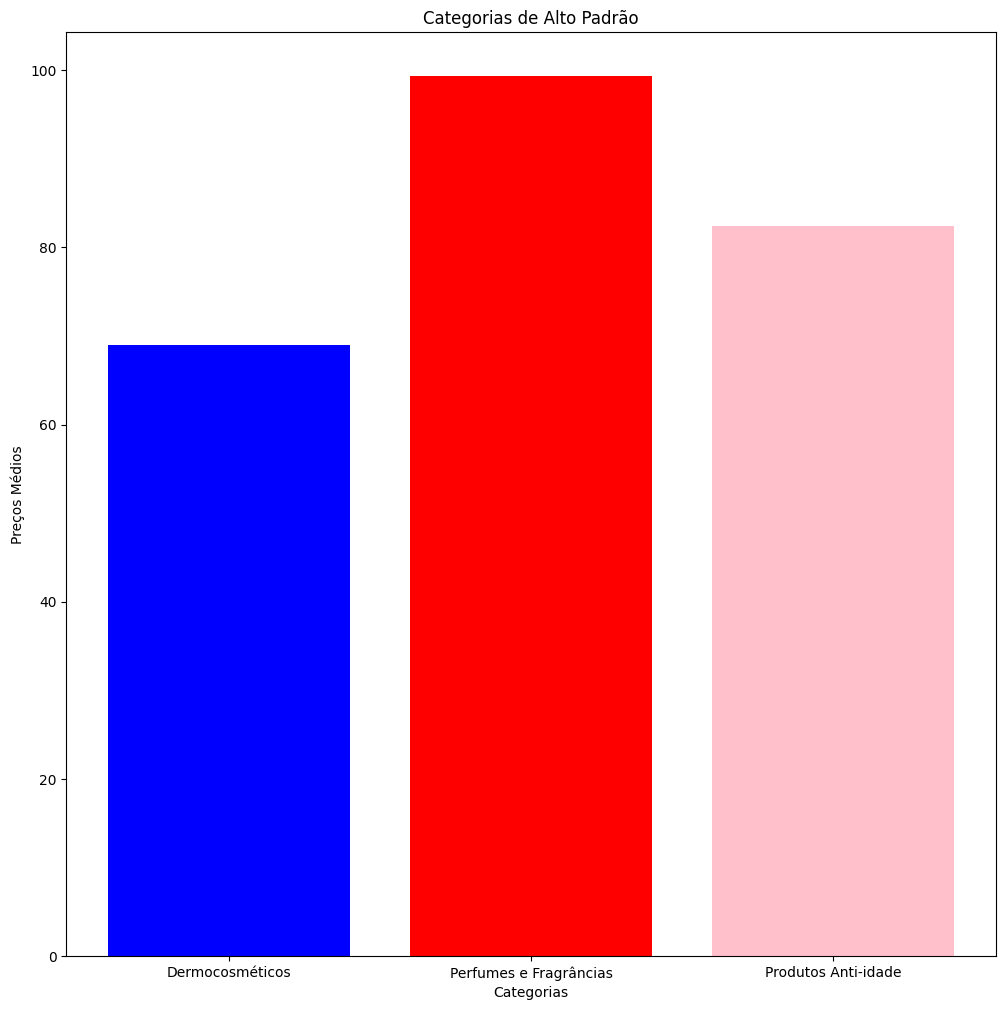

In [67]:
import matplotlib.pyplot as plt

cores = ["blue","red","pink"]

categorias = [categoria[0] for categoria in categorias_alto_padrao]
precos_medios = [preco[1] for preco in categorias_alto_padrao]
cores_barras = [cor for cor in cores] 

plt.figure(figsize=(12,12))

plt.bar(categorias,precos_medios, color=cores_barras)

plt.xlabel("Categorias")
plt.ylabel("Preços Médios")
plt.title("Categorias de Alto Padrão")

plt.show()


9. Relação de Produtos por Faixa Exclusiva de Preço

 Objetivo: Analisar o volume de produtos que custam entre R$ 30,00
e R$ 80,00 dentro de cada categoria.

 Desafio SQL/Python: Aplicar o filtro no WHERE (usando
BETWEEN), fazer o JOIN, agrupar por categoria para contar os
produtos que se encaixam nessa faixa e ordenar pelo volume
encontrado.

Plote um gráfico de colunas.

In [70]:
comando_relacao_produto_faixa_preco = '''
SELECT
    categorias.nome,
    SUM(produtos.estoque)
FROM produtos
INNER JOIN categorias ON produtos.id_categoria = categorias.id_categoria
WHERE produtos.preco BETWEEN 30 AND 80
GROUP BY categorias.nome;
'''

cursor.execute(comando_relacao_produto_faixa_preco)
relacao_produto_faixa_preco = cursor.fetchall()

print("\n--- Relação Produtos e Faixa de Preço ---\n")

for i in relacao_produto_faixa_preco:
    print(f"Categoria: {i[0]} | Quantidade: {i[1]}")



--- Relação Produtos e Faixa de Preço ---

Categoria: Maquiagem | Quantidade: 95
Categoria: Cuidados com o Cabelo | Quantidade: 105
Categoria: Proteção Solar | Quantidade: 100
Categoria: Produtos Anti-idade | Quantidade: 25
Categoria: Produtos Naturais e Orgânicos | Quantidade: 40
Categoria: Cuidados com a Pele | Quantidade: 50
Categoria: Perfumes e Fragrâncias | Quantidade: 35
Categoria: Dermocosméticos | Quantidade: 30
Categoria: Cuidados Masculinos | Quantidade: 25


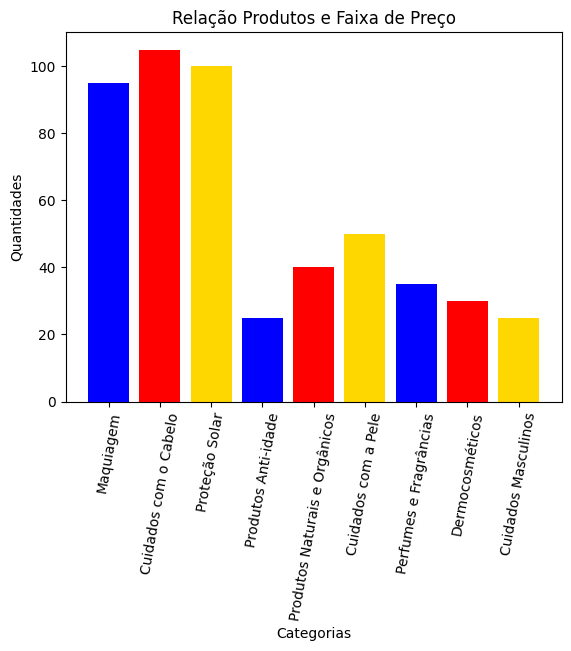

In [75]:
import matplotlib.pyplot as plt

cores = ["blue","red","gold"]

categorias = [categoria[0] for categoria in relacao_produto_faixa_preco]
quantidades = [quantidade[1] for quantidade in relacao_produto_faixa_preco]
cores_barras = [cor for cor in cores]

plt.bar(categorias,quantidades,color = cores_barras)

plt.xlabel("Categorias")
plt.ylabel("Quantidades")
plt.title("Relação Produtos e Faixa de Preço")

plt.xticks(rotation=80)

plt.show()

10. Relatório Consolidado de Desempenho de Catálogo

 Objetivo: Gerar um relatório completo para a diretoria contendo o
nome da categoria, o total de produtos cadastrados e a média de
preço simultaneamente.

 Desafio SQL/Python: Unir produtos e categorias, agrupar por
categoria puxando múltiplos agregadores (COUNT(p.id) e
AVG(p.preco)) no mesmo SELECT, ordenando o resultado final por
ordem alfabética (ORDER BY c.nome ASC).

Exiba os dados em um painel
composto (subplots lado a lado).

In [86]:
comando_relatorio_desempenho_catalogo = '''
SELECT
    categorias.nome,
    COUNT(produtos.id_produto),
    AVG(produtos.preco)
FROM produtos
INNER JOIN categorias on produtos.id_categoria = categorias.id_categoria
GROUP BY categorias.nome
ORDER BY categorias.nome ASC
'''

cursor.execute(comando_relatorio_desempenho_catalogo)
relatorio_desempenho_catalogo = cursor.fetchall()

print("\n--- Relatório de Desempenhp de Catálogo ---\n")
for i in relatorio_desempenho_catalogo:
    print(f"Categoria: {i[0]} | Quantidade Cadastrada: {i[1]} | Preço Médio: {i[2]:.2f}")


--- Relatório de Desempenhp de Catálogo ---

Categoria: Cuidados com a Pele | Quantidade Cadastrada: 4 | Preço Médio: 26.55
Categoria: Cuidados com o Cabelo | Quantidade Cadastrada: 4 | Preço Médio: 38.40
Categoria: Cuidados Masculinos | Quantidade Cadastrada: 2 | Preço Médio: 29.45
Categoria: Dermocosméticos | Quantidade Cadastrada: 2 | Preço Médio: 68.95
Categoria: Higiene Pessoal | Quantidade Cadastrada: 3 | Preço Médio: 16.23
Categoria: Maquiagem | Quantidade Cadastrada: 6 | Preço Médio: 38.85
Categoria: Perfumes e Fragrâncias | Quantidade Cadastrada: 3 | Preço Médio: 99.30
Categoria: Produtos Anti-idade | Quantidade Cadastrada: 2 | Preço Médio: 82.45
Categoria: Produtos Naturais e Orgânicos | Quantidade Cadastrada: 2 | Preço Médio: 33.95
Categoria: Proteção Solar | Quantidade Cadastrada: 2 | Preço Médio: 42.70


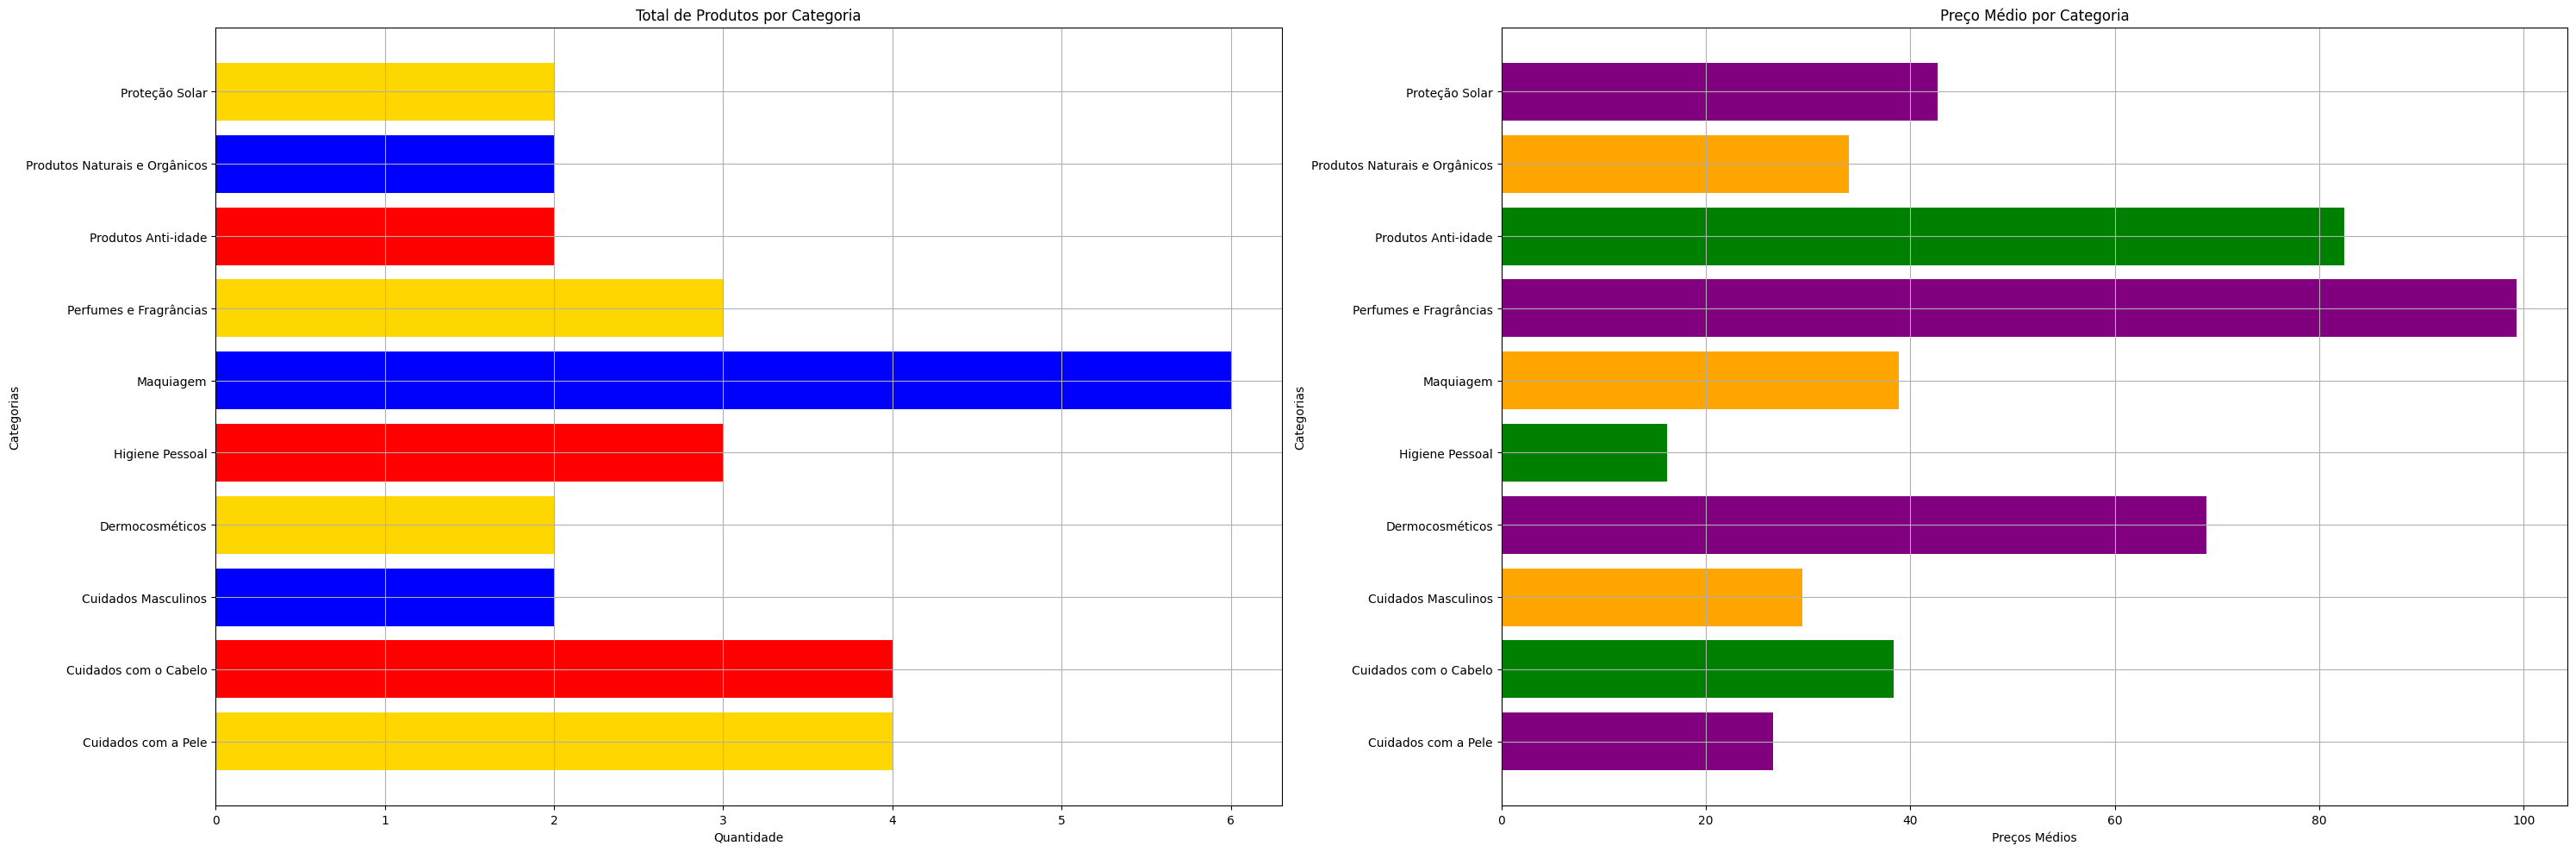

In [87]:
import matplotlib.pyplot as plt

cores_grafico1 = ["gold","red","blue"]
cores_grafico2 = ["purple","green","orange"]

categorias = [categoria[0] for categoria in relatorio_desempenho_catalogo]
quantidade_cadastrada = [quantidade[1] for quantidade in relatorio_desempenho_catalogo]
preco_medio = [preco[2] for preco in relatorio_desempenho_catalogo]
cores1 = [cor for cor in cores_grafico1]
cores2 = [cor for cor in cores_grafico2]

fig, ax = plt.subplots(1, 2, figsize=(30, 10))

ax[0].barh(categorias,quantidade_cadastrada,color=cores1)
ax[0].set_title("Total de Produtos por Categoria")
ax[0].set_xlabel("Quantidade")
ax[0].set_ylabel("Categorias")
ax[0].grid(True)

ax[1].barh(categorias,preco_medio,color=cores2)
ax[1].set_title("Preço Médio por Categoria")
ax[1].set_xlabel("Preços Médios")
ax[1].set_ylabel("Categorias")
ax[1].grid(True)

plt.tight_layout()
plt.show()



In [88]:
#Fechando Conexão
cursor.close()
conexao.close()

print("Conexão Fechada!")

Conexão Fechada!
